In [1]:
"""
Grid search for DTS-ESN (Diverse-Timescale Echo State Network)
closed-loop prediction of the Rulkov map.

Follows Tanaka, Matsumori, Yoshida, Aihara,
  "Reservoir computing with diverse timescales for prediction of multiscale
  dynamics", Phys. Rev. Research 4, L032014 (2022).

Structure mirrors the classic-ESN grid search script: define a parameter
grid, evaluate each combination by scaled-space NRMSE, retrain the best
configuration, then plot.

Notes on the swept parameters
-----------------------------
- alpha_min / alpha_max : bounds of the log-uniform leak-rate distribution.
  The paper's Rulkov/Task 2 setting is alpha_min = 10**(-6/9), alpha_max = 1.
  We sweep a couple of options around that.
- sr, input_scaling, fb_scaling, ridge : same role as in the classic ESN.
- density : fraction of nonzero entries in W (d in the paper, default 0.1).
"""

import itertools
import time
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..',)))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)


# ==========================================================
# DTS-ESN CLASS
# ==========================================================
class DTSESN:
    """
    Diverse-Timescale Echo State Network with output feedback.

    State update (Eqs. 1-3 of the paper, Task 2 / closed-loop variant):

        x(t+dt) = (I - A) x(t)
                + A * tanh( rho*W x(t) + gamma*Win u(t+dt) + zeta*Wfb y(t) )
        y(t+dt) = W_out x(t+dt)

    with A = diag(alpha_1, ..., alpha_Nx) and alpha_i drawn from a reciprocal
    (log-uniform) distribution on [alpha_min, alpha_max].
    """

    def __init__(
        self,
        n_inputs,
        n_outputs,
        n_reservoir=400,
        alpha_min=10 ** (-6 / 9),
        alpha_max=1.0,
        spectral_radius=1.0,
        input_scaling=0.8,
        fb_scaling=1.0,
        density=0.1,
        ridge=1e-3,
        seed=42,
    ):
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs
        self.n_reservoir = n_reservoir
        self.alpha_min = alpha_min
        self.alpha_max = alpha_max
        self.spectral_radius = spectral_radius
        self.input_scaling = input_scaling
        self.fb_scaling = fb_scaling
        self.density = density
        self.ridge = ridge
        self.rng = np.random.default_rng(seed)

        self._build_weights()
        self._build_leak_rates()
        self.reset_state()

        self.W_out = None

    # ----------------------------------------------------------
    def _build_weights(self):
        Nx = self.n_reservoir

        W = self.rng.uniform(-1.0, 1.0, size=(Nx, Nx))
        mask = self.rng.uniform(0.0, 1.0, size=(Nx, Nx)) < self.density
        W = W * mask

        eigvals = np.linalg.eigvals(W)
        current_sr = np.max(np.abs(eigvals))
        if current_sr > 0:
            W = W / current_sr
        self.W = self.spectral_radius * W

        self.W_in = self.rng.uniform(-1.0, 1.0, size=(Nx, self.n_inputs))
        self.W_fb = self.rng.uniform(-1.0, 1.0, size=(Nx, self.n_outputs))

    # ----------------------------------------------------------
    def _build_leak_rates(self):
        log_min = np.log10(self.alpha_min)
        log_max = np.log10(self.alpha_max)
        if log_min == log_max:
            self.alphas = np.full(self.n_reservoir, self.alpha_max)
        else:
            log_alphas = self.rng.uniform(
                log_min, log_max, size=self.n_reservoir
            )
            self.alphas = 10.0 ** log_alphas

    # ----------------------------------------------------------
    def reset_state(self):
        self.x = np.zeros(self.n_reservoir)
        self.y = np.zeros(self.n_outputs)

    # ----------------------------------------------------------
    def _update(self, u, y_prev):
        pre = (
            self.W @ self.x
            + self.input_scaling * (self.W_in @ u)
            + self.fb_scaling * (self.W_fb @ y_prev)
        )
        self.x = (1.0 - self.alphas) * self.x + self.alphas * np.tanh(pre)
        return self.x

    # ----------------------------------------------------------
    def harvest_states(self, U, Y_teacher, washout=0):
        T = U.shape[0]
        X = np.zeros((T, self.n_reservoir))
        self.reset_state()

        y_prev = np.zeros(self.n_outputs)
        for t in range(T):
            self._update(U[t], y_prev)
            X[t] = self.x
            y_prev = Y_teacher[t]

        return X[washout:]

    # ----------------------------------------------------------
    def fit(self, U, Y, washout=100):
        X = self.harvest_states(U, Y, washout=washout)
        Y_target = Y[washout:]

        Nx = self.n_reservoir
        A = X.T @ X + self.ridge * np.eye(Nx)
        B = X.T @ Y_target
        self.W_out = np.linalg.solve(A, B).T
        return self

    # ----------------------------------------------------------
    def run_open_loop(self, U, Y_teacher=None):
        T = U.shape[0]
        preds = np.zeros((T, self.n_outputs))
        y_prev = self.y.copy()

        for t in range(T):
            self._update(U[t], y_prev)
            y_hat = self.W_out @ self.x
            preds[t] = y_hat
            if Y_teacher is not None:
                y_prev = Y_teacher[t]
            else:
                y_prev = y_hat

        self.y = y_prev
        return preds

    # ----------------------------------------------------------
    def run_closed_loop(self, n_steps, u0):
        preds = np.zeros((n_steps, self.n_outputs))
        u = np.asarray(u0).reshape(self.n_inputs)
        y_prev = self.y.copy()

        for t in range(n_steps):
            self._update(u, y_prev)
            y_hat = self.W_out @ self.x
            preds[t] = y_hat
            u = y_hat
            y_prev = y_hat

        return preds

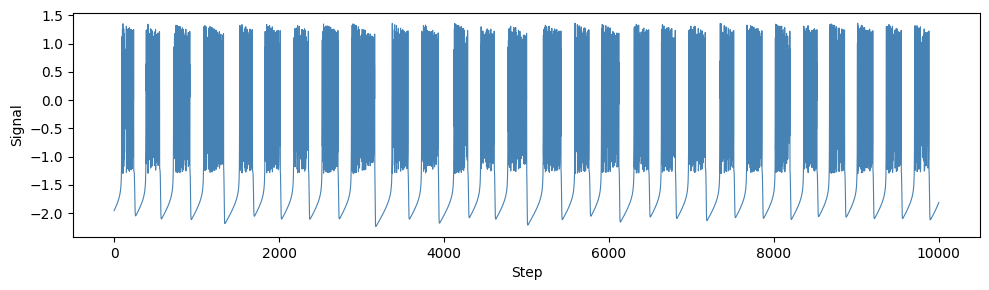

In [5]:
# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[:, 0]
data = dataset.reshape(-1, 1)

X_raw = data[:-1]
Y_raw = data[1:]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

Total combinations to evaluate: 17280
[50/17280]  elapsed: 7s  ETA: 2279s  current best NRMSE: 1.171411
[100/17280]  elapsed: 13s  ETA: 2265s  current best NRMSE: 0.973770
[150/17280]  elapsed: 20s  ETA: 2267s  current best NRMSE: 0.973770
[200/17280]  elapsed: 27s  ETA: 2285s  current best NRMSE: 0.973770
[250/17280]  elapsed: 35s  ETA: 2404s  current best NRMSE: 0.973770
[300/17280]  elapsed: 42s  ETA: 2389s  current best NRMSE: 0.973770
[350/17280]  elapsed: 49s  ETA: 2371s  current best NRMSE: 0.973770
[400/17280]  elapsed: 56s  ETA: 2361s  current best NRMSE: 0.973770
[450/17280]  elapsed: 63s  ETA: 2355s  current best NRMSE: 0.973770
[500/17280]  elapsed: 70s  ETA: 2337s  current best NRMSE: 0.973770
[550/17280]  elapsed: 76s  ETA: 2323s  current best NRMSE: 0.973770
[600/17280]  elapsed: 83s  ETA: 2308s  current best NRMSE: 0.973770
[650/17280]  elapsed: 90s  ETA: 2295s  current best NRMSE: 0.973770
[700/17280]  elapsed: 96s  ETA: 2281s  current best NRMSE: 0.973770
[750/17280] 

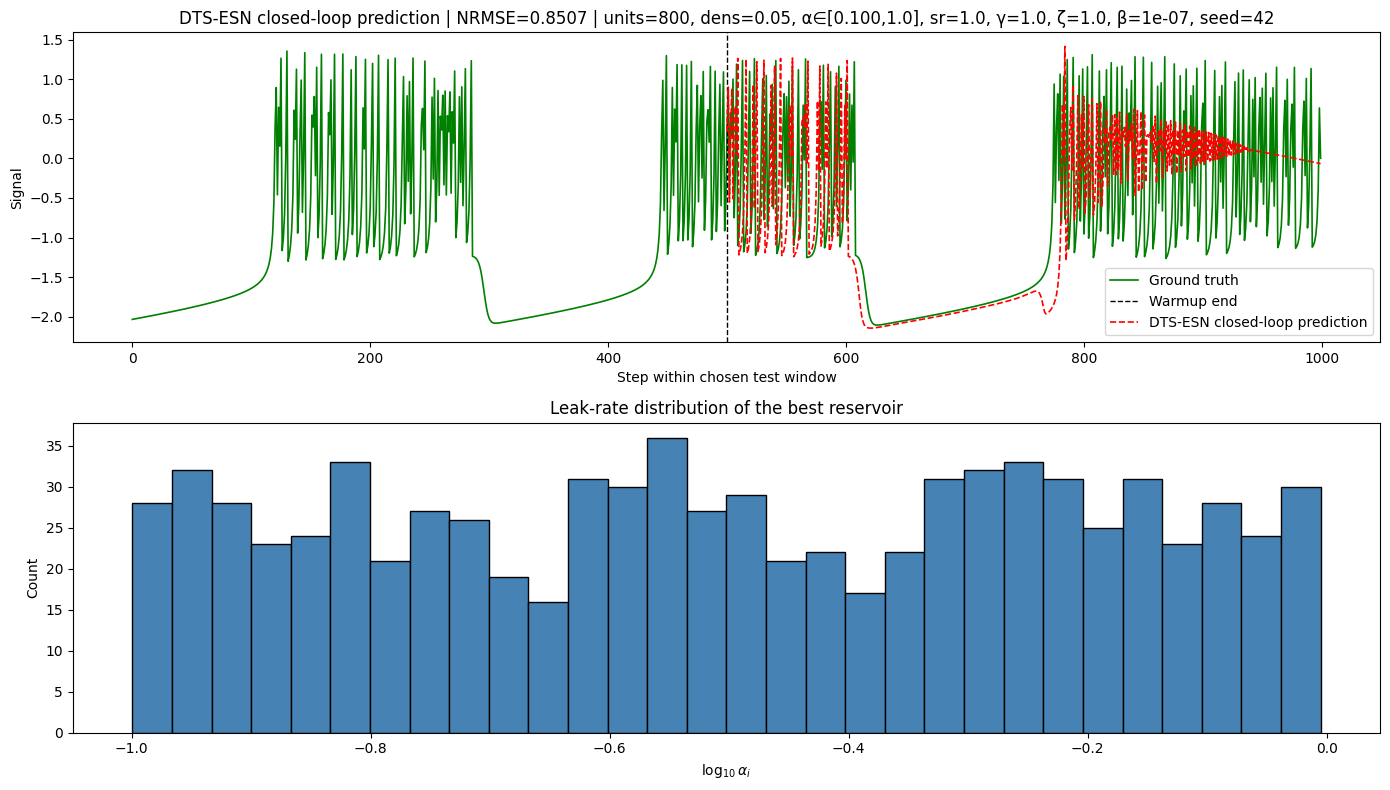

In [6]:
# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len = 4000
test_start = 4000
test_len = 1000

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]

X_test_raw = X_raw[test_start:test_start + test_len]
Y_test_raw = Y_raw[test_start:test_start + test_len]


# ==========================================================
# PARAMETER GRID  (expanded)
# ==========================================================
# alpha_min sweep: dense log spacing from 10^-3 (very slow/diverse) up to
# 10^0 (no diversity = standard LI-ESN). This covers the full horizontal
# axis of the paper's Fig. 6(a).
alpha_min_sweep = [
    10 ** (-3.0),
    10 ** (-2.5),
    10 ** (-2.0),
    10 ** (-1.5),
    10 ** (-6 / 9),   # paper's Rulkov/Task 2 value (≈ 0.2154)
    10 ** (-1.0),
    10 ** (-0.5),
    10 ** (-0.1),
]

param_grid = {
    "normalization":   ["zscore"],
    "train_warmup":    [200],
    "test_warmup":     [500],
    "units":           [400, 800],
    "density":         [0.05, 0.1],
    "alpha_min":       alpha_min_sweep,
    "alpha_max":       [1.0],
    "sr":              [0.8, 0.95, 1.0, 1.1, 1.3],
    "input_scaling":   [0.3, 0.6, 0.8, 1.0],
    "fb_scaling":      [0.0, 0.5, 1.0],
    "ridge":           [1e-7, 1e-5, 1e-3],
    "seed":            [13, 42, 77],   # average over 3 reservoir realizations
}

keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))

print(f"Total combinations to evaluate: {len(combos)}")


# ==========================================================
# EVALUATION FUNCTION
# ==========================================================
def evaluate_dtsesn(
    normalization,
    train_warmup,
    test_warmup,
    units,
    density,
    alpha_min,
    alpha_max,
    sr,
    input_scaling,
    fb_scaling,
    ridge,
    seed,
):
    """
    Build, train, synchronize, and run closed-loop prediction.
    Return NRMSE in scaled space for hyperparameter search.
    """
    try:
        if test_warmup >= test_len:
            return np.inf

        scaler = fit_scaler(X_train_raw, method=normalization)

        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test = transform_array(X_test_raw, scaler)
        Y_test = transform_array(Y_test_raw, scaler)

        pred_len = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, 0]

        if train_warmup >= len(X_train):
            return np.inf

        esn = DTSESN(
            n_inputs=1,
            n_outputs=1,
            n_reservoir=int(units),
            alpha_min=alpha_min,
            alpha_max=alpha_max,
            spectral_radius=sr,
            input_scaling=input_scaling,
            fb_scaling=fb_scaling,
            density=density,
            ridge=ridge,
            seed=seed,
        )

        esn.fit(X_train, Y_train, washout=train_warmup)

        esn.reset_state()

        if test_warmup > 0:
            _ = esn.run_open_loop(
                X_test[:test_warmup],
                Y_teacher=Y_test[:test_warmup],
            )

        u0 = X_test[test_warmup]
        Y_pred_scaled = esn.run_closed_loop(pred_len, u0=u0).ravel()

        if np.any(np.isnan(Y_pred_scaled)) or np.any(np.isinf(Y_pred_scaled)):
            return np.inf
        if np.max(np.abs(Y_pred_scaled)) > 1e6:
            return np.inf

        rmse = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2))
        denom = np.std(Y_true_scaled)
        if denom == 0:
            return np.inf

        return rmse / denom

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_dtsesn(**params)
    results.append({**params, "nrmse": nrmse})

    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    if (i + 1) % 50 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        eta = elapsed / (i + 1) * (len(combos) - i - 1)
        print(
            f"[{i+1}/{len(combos)}]  "
            f"elapsed: {elapsed:.0f}s  "
            f"ETA: {eta:.0f}s  "
            f"current best NRMSE: {best_nrmse:.6f}"
        )

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("GRID SEARCH COMPLETE")
print(f"Train interval      : [0 : {train_len}]")
print(f"Test interval       : [{test_start} : {test_start + test_len}]")
print(f"Total time          : {total_time:.1f}s "
      f"({total_time/len(combos):.2f}s per trial)")
print(f"Model               : DTS-ESN (ridge readout)")
print(f"Best NRMSE          : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:24s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 15 configurations:")
print(
    f"{'Rank':>4}  {'units':>5}  {'dens':>5}  "
    f"{'a_min':>7}  {'sr':>4}  "
    f"{'in_sc':>5}  {'fb':>4}  {'ridge':>8}  {'seed':>4}  {'NRMSE':>10}"
)
print("-" * 100)

for rank, r in enumerate(results_sorted[:15], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['units']):5d}  "
        f"{r['density']:5.2f}  "
        f"{r['alpha_min']:7.4f}  "
        f"{r['sr']:4.2f}  "
        f"{r['input_scaling']:5.2f}  "
        f"{r['fb_scaling']:4.1f}  "
        f"{r['ridge']:8.1e}  "
        f"{int(r['seed']):4d}  "
        f"{r['nrmse']:10.6f}"
    )


# ==========================================================
# AGGREGATE BY (ALL PARAMS EXCEPT SEED)
# ==========================================================
# With multiple seeds, rank by mean NRMSE across seeds — this is more
# honest than trusting a single lucky reservoir.
from collections import defaultdict

grouped = defaultdict(list)
group_keys = [k for k in keys if k != "seed"]

for r in results:
    key = tuple(r[k] for k in group_keys)
    grouped[key].append(r["nrmse"])

aggregated = []
for key, nrmses in grouped.items():
    nrmses = np.array(nrmses)
    finite = nrmses[np.isfinite(nrmses)]
    if len(finite) == 0:
        continue
    aggregated.append({
        **dict(zip(group_keys, key)),
        "mean_nrmse": np.mean(finite),
        "std_nrmse": np.std(finite),
        "n_finite": len(finite),
    })

aggregated_sorted = sorted(aggregated, key=lambda r: r["mean_nrmse"])

print("\nTop 15 configurations averaged over seeds "
      "(only configs with at least 1 finite run):")
print(
    f"{'Rank':>4}  {'units':>5}  {'dens':>5}  "
    f"{'a_min':>7}  {'sr':>4}  "
    f"{'in_sc':>5}  {'fb':>4}  {'ridge':>8}  "
    f"{'mean':>8}  {'std':>8}  {'n':>3}"
)
print("-" * 100)

for rank, r in enumerate(aggregated_sorted[:15], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['units']):5d}  "
        f"{r['density']:5.2f}  "
        f"{r['alpha_min']:7.4f}  "
        f"{r['sr']:4.2f}  "
        f"{r['input_scaling']:5.2f}  "
        f"{r['fb_scaling']:4.1f}  "
        f"{r['ridge']:8.1e}  "
        f"{r['mean_nrmse']:8.4f}  "
        f"{r['std_nrmse']:8.4f}  "
        f"{int(r['n_finite']):3d}"
    )


# ==========================================================
# REBUILD BEST MODEL (best single-trial NRMSE)
# ==========================================================
best_scaler = fit_scaler(X_train_raw, method=best_params["normalization"])

X_train_best = transform_array(X_train_raw, best_scaler)
Y_train_best = transform_array(Y_train_raw, best_scaler)
X_test_best = transform_array(X_test_raw, best_scaler)
Y_test_best = transform_array(Y_test_raw, best_scaler)

best_pred_len = test_len - best_params["test_warmup"]

best_esn = DTSESN(
    n_inputs=1,
    n_outputs=1,
    n_reservoir=int(best_params["units"]),
    alpha_min=best_params["alpha_min"],
    alpha_max=best_params["alpha_max"],
    spectral_radius=best_params["sr"],
    input_scaling=best_params["input_scaling"],
    fb_scaling=best_params["fb_scaling"],
    density=best_params["density"],
    ridge=best_params["ridge"],
    seed=best_params["seed"],
)

best_esn.fit(
    X_train_best,
    Y_train_best,
    washout=best_params["train_warmup"],
)

best_esn.reset_state()

if best_params["test_warmup"] > 0:
    _ = best_esn.run_open_loop(
        X_test_best[:best_params["test_warmup"]],
        Y_teacher=Y_test_best[:best_params["test_warmup"]],
    )

u0 = X_test_best[best_params["test_warmup"]]
Y_pred_best_scaled = best_esn.run_closed_loop(best_pred_len, u0=u0)

Y_true_best_scaled = Y_test_best[
    best_params["test_warmup"]:best_params["test_warmup"] + best_pred_len
]

Y_pred_best = inverse_transform_array(Y_pred_best_scaled, best_scaler).ravel()
Y_true_best = inverse_transform_array(Y_true_best_scaled, best_scaler).ravel()

mse = np.mean((Y_true_best - Y_pred_best) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true_best)

print("\nFinal best-model metrics in original scale:")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")


# ==========================================================
# VISUALIZATION
# ==========================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
ax.plot(
    np.arange(test_len),
    Y_test_raw[:, 0],
    c="green",
    label="Ground truth",
    linewidth=1.2,
)
ax.axvline(
    best_params["test_warmup"],
    linestyle="--",
    c="k",
    linewidth=1.0,
    label="Warmup end",
)
ax.plot(
    np.arange(
        best_params["test_warmup"],
        best_params["test_warmup"] + best_pred_len,
    ),
    Y_pred_best,
    linestyle="--",
    c="red",
    linewidth=1.2,
    label="DTS-ESN closed-loop prediction",
)
ax.set_title(
    f"DTS-ESN closed-loop prediction | NRMSE={nrmse:.4f} | "
    f"units={int(best_params['units'])}, "
    f"dens={best_params['density']}, "
    f"α∈[{best_params['alpha_min']:.3f},{best_params['alpha_max']}], "
    f"sr={best_params['sr']}, "
    f"γ={best_params['input_scaling']}, "
    f"ζ={best_params['fb_scaling']}, "
    f"β={best_params['ridge']:.0e}, "
    f"seed={best_params['seed']}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()

ax = axes[1]
ax.hist(np.log10(best_esn.alphas), bins=30, color="steelblue", edgecolor="k")
ax.set_xlabel(r"$\log_{10}\alpha_i$")
ax.set_ylabel("Count")
ax.set_title("Leak-rate distribution of the best reservoir")

plt.tight_layout()
plt.show()